co Random Forest MSE: 1.891005031691559


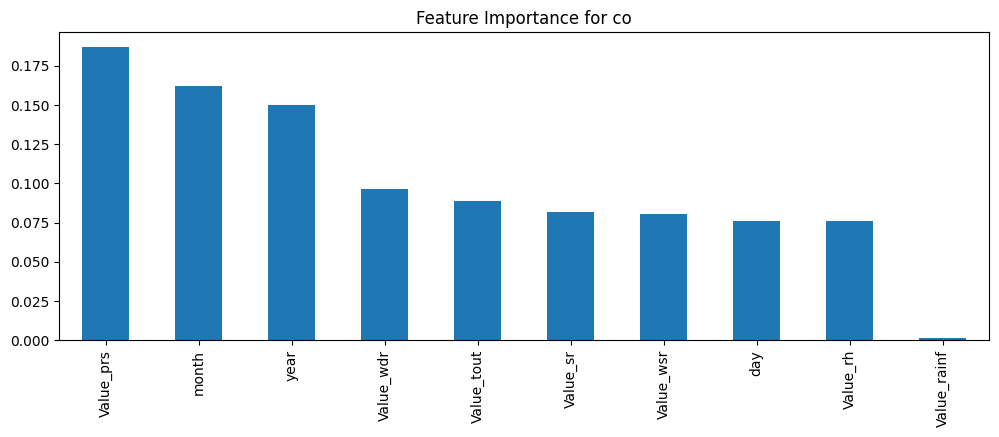

c:\Users\santi\OneDrive\Documents\GitHub\PROYECTO_MA2003B\venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
c:\Users\santi\OneDrive\Documents\GitHub\PROYECTO_MA2003B\venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
c:\Users\santi\OneDrive\Documents\GitHub\PROYECTO_MA2003B\venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
c:\Users\santi\OneDrive\Documents\GitHub\PROYECTO_MA2003B\venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
c:\Users\santi\OneDrive\Documents\GitHub\PROYECTO_MA2003B\venv\Lib\site-packages\sklearn\utils\valid

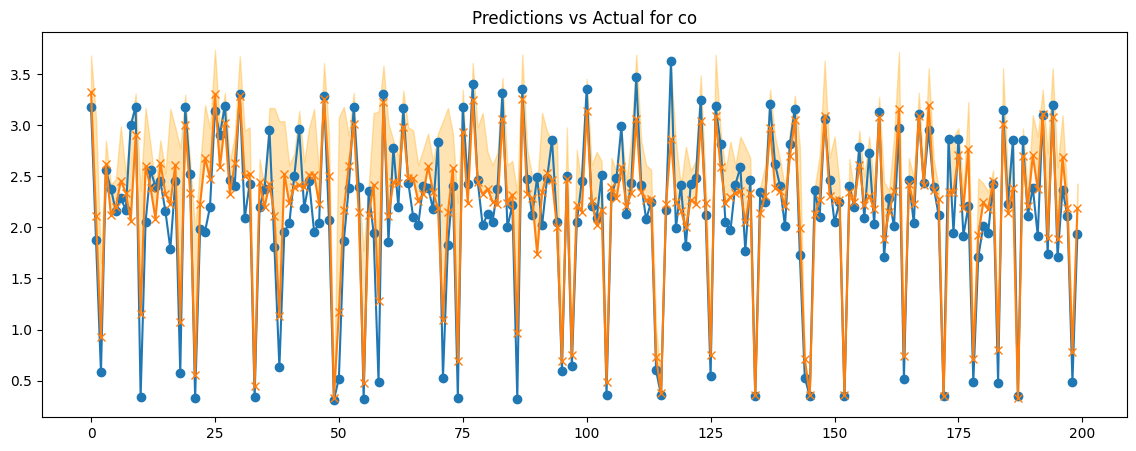

Cross-Validation MSE: -0.98
no Random Forest MSE: 213.35178685091995


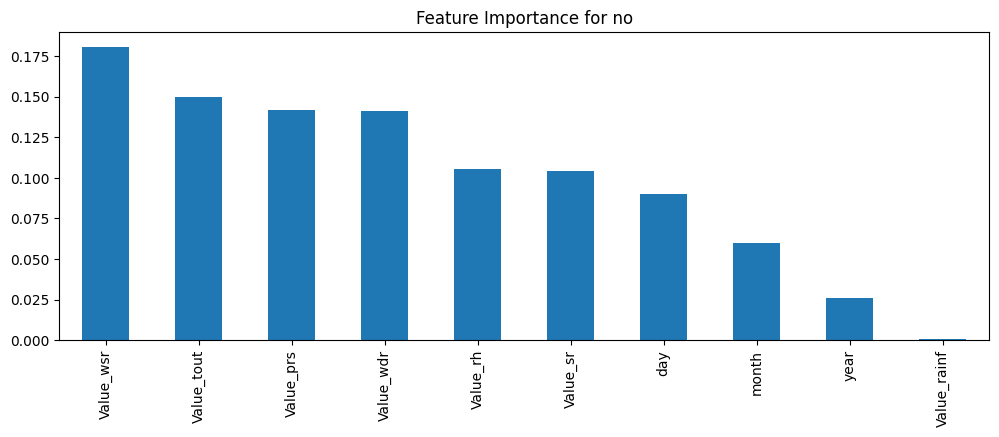

c:\Users\santi\OneDrive\Documents\GitHub\PROYECTO_MA2003B\venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
c:\Users\santi\OneDrive\Documents\GitHub\PROYECTO_MA2003B\venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
c:\Users\santi\OneDrive\Documents\GitHub\PROYECTO_MA2003B\venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
c:\Users\santi\OneDrive\Documents\GitHub\PROYECTO_MA2003B\venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
c:\Users\santi\OneDrive\Documents\GitHub\PROYECTO_MA2003B\venv\Lib\site-packages\sklearn\utils\valid

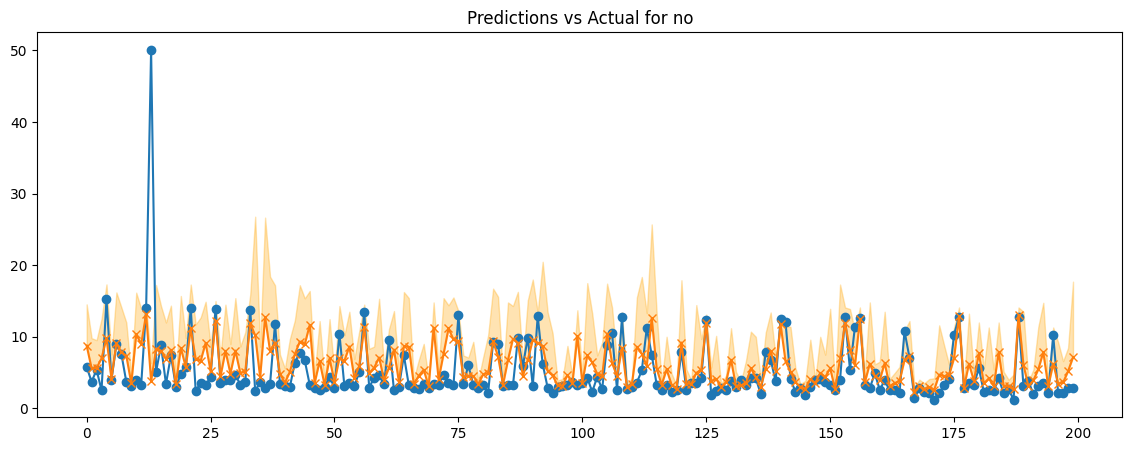

Cross-Validation MSE: -328.83
so2 Random Forest MSE: 10.429898028800864


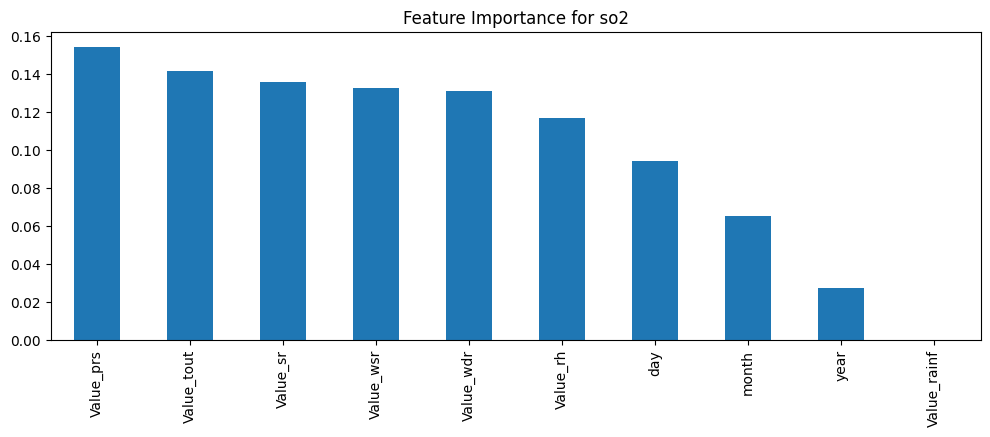

c:\Users\santi\OneDrive\Documents\GitHub\PROYECTO_MA2003B\venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
c:\Users\santi\OneDrive\Documents\GitHub\PROYECTO_MA2003B\venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
c:\Users\santi\OneDrive\Documents\GitHub\PROYECTO_MA2003B\venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
c:\Users\santi\OneDrive\Documents\GitHub\PROYECTO_MA2003B\venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
c:\Users\santi\OneDrive\Documents\GitHub\PROYECTO_MA2003B\venv\Lib\site-packages\sklearn\utils\valid

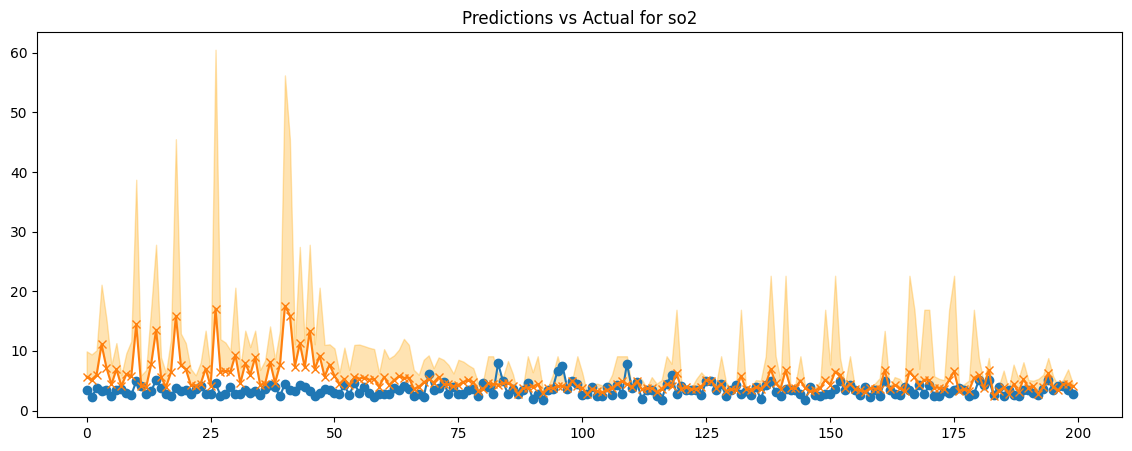

Cross-Validation MSE: -17.91


In [5]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score

# Load data
df = pd.read_csv("consolidated_outliers.csv", parse_dates=["date_index"])

# Extract date components
df['year'] = df['date_index'].dt.year
df['month'] = df['date_index'].dt.month
df['day'] = df['date_index'].dt.day
df['hour'] = df['date_index'].dt.hour

# Define time of day
def time_of_day(hour):
    if 0 <= hour < 6:
        return "early_morning"
    elif 6 <= hour < 12:
        return "morning"
    elif 12 <= hour < 18:
        return "afternoon"
    else:
        return "night"

df['time_of_day'] = df['hour'].apply(time_of_day)

# Remove outliers
all_vars = ['co','no','no2','nox','o3','pm10','pm2.5','so2',
            'wsr', 'prs', 'rainf', 'rh', 'sr', 'tout', 'wdr']
mask = np.ones(len(df), dtype=bool)
for var in all_vars:
    mask &= df[f'Ind_outlier_{var}'] != 1
df_clean = df[mask].copy()

# Define predictors and pollutants
# Corrected weather variables
weather_vars = ['Value_wsr', 'Value_prs', 'Value_rainf', 'Value_rh', 'Value_sr', 'Value_tout', 'Value_wdr']
date_vars = ['year', 'month', 'day']
categorical_vars = ['time_of_day']
pollutants = ['co', 'no', 'so2']


# One-hot encode time_of_day
df_clean = pd.get_dummies(df, columns=categorical_vars, drop_first=False)

# Train Random Forest for each pollutant
predictors = weather_vars + date_vars + [col for col in df.columns if col.startswith('time_of_day_')]

for pollutant in pollutants:
    df_model = df_clean.dropna(subset=predictors + [f'Value_{pollutant}'])
    X = df_model[predictors]
    y = df_model[f'Value_{pollutant}']
    
    # Keep track of indices for plotting later
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, shuffle=False
    )
    
    rf = RandomForestRegressor(n_estimators=200, random_state=42)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    print(f"{pollutant} Random Forest MSE:", mse)
    
    # Feature importance
    importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
    plt.figure(figsize=(12,4))
    importances.plot(kind='bar')
    plt.title(f"Feature Importance for {pollutant}")
    plt.show()
    
    # Predictions vs Actual with 90th percentile upper bound
    plt.figure(figsize=(14,5))

    # Get predictions from each tree
    all_tree_preds = np.array([tree.predict(X_test) for tree in rf.estimators_])  # shape: (n_trees, n_samples)

    # Mean prediction
    y_pred_mean = all_tree_preds.mean(axis=0)

    # 90th percentile
    y_pred_90th = np.percentile(all_tree_preds, 90, axis=0)

    # Limit to first 200 points for readability
    n_points = 200
    x_vals = np.arange(n_points)

    plt.plot(x_vals, y_test.values[:n_points], label="Actual", marker='o')
    plt.plot(x_vals, y_pred_mean[:n_points], label="Predicted", marker='x')

    # Plot 90th percentile bound as shaded area
    plt.fill_between(
        x_vals,
        y_pred_mean[:n_points],
        y_pred_90th[:n_points],
        color='orange', alpha=0.3, label='Up to 90th percentile'
    )

    plt.title(f"Predictions vs Actual for {pollutant}")
    plt.show()
    scores = cross_val_score(rf, X, y, cv=5, scoring='neg_mean_squared_error')
    print(f"Cross-Validation MSE: {scores.mean():.2f}")
